### First, Setup the local cluster

In [ ]:
from dask.distributed import Client

client = Client(n_workers=4)
client

**Dask Dashboard**

*Please be aware that Google Colab operates on a remote machine for computation; thus, you should use the version of Jupyter Notebook installed on your own computer to access the dashboard.*

Dask Distributed provides a useful Dashboard to visualize the state of your cluster and computations.
Simply click on the dashboard link displayed in the Client details above: http://127.0.0.1:8787/status. It will open a new browser tab with the Dashboard.

We can focus in the status tab which consists of **"Task Stream"**, **"Progress Bar"**, and **"Worker Memory"**

### 1. Dask Arrays: Parallelized Numpy

Dask Array provides a portion of the NumPy ndarray interface by utilizing blocked algorithms, which divide a large array into multiple smaller arrays. It enables computations on arrays that exceed memory capacity by leveraging all available CPU cores.

This section enables us to grasp the underlying mechanisms by implementing some blocked algorithms from scratch.

#### 1.1 Blocked Algorithms

In [3]:
import numpy as np
import dask.array as da

To begin, we first create a one-dimensional array containing 20 elements.

In [30]:
arr = np.ones(20)
arr

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

To calculate the total of all the elements in the array, we can use the `sum()` function.

In [7]:
print(arr.sum())

20.0


However, we can also calculate the sum of the first half of the array and the second half in parallel.

In [24]:
print(arr[:int(len(arr)/2)].sum() + arr[int(len(arr)/2):].sum())

20.0


Keep in mind that each sum in the above computation is entirely independent, allowing them to be processed in parallel.

To achieve this with a Dask array, we need to define our "slices" by specifying the number of elements we want per block using the variable `chunks`.

In [26]:
arr_da = da.ones(20, chunks=10)
arr_da

dask.array<ones_like, shape=(20,), dtype=float64, chunksize=(10,), chunktype=numpy.ndarray>

From the output above, we can observe that there are two blocks. By specifying chunks=10, we indicate that each block contains 10 elements.

In [29]:
arr_da_sum = arr_da.sum()
arr_da_sum

dask.array<sum-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>

The result did not display any output. Since Dask employs lazy evaluation, it first constructs the representation's structure. We  often referred this as lazy output.

#### 1.2 Task Graph

In Dask, we utilize task scheduling to divide our program into smaller computational tasks.

These tasks are represented as nodes in a graph, with edges connecting nodes when one task relies on data generated by another.

A task scheduler is then employed to execute this graph, ensuring that data dependencies are maintained while maximizing parallelism, allowing multiple independent tasks to run simultaneously.

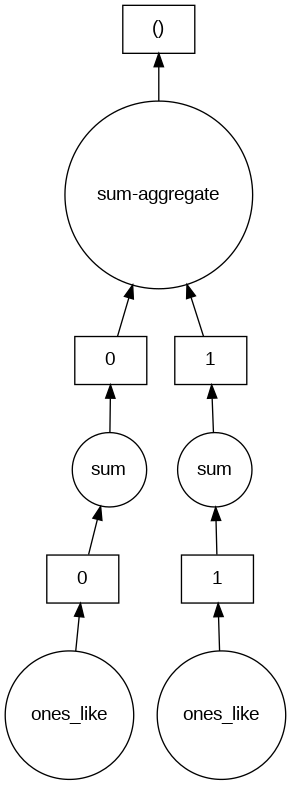

In [30]:
arr_da_sum.visualize()

In [32]:
print(arr_da_sum.compute())

20.0


#### 1.3 Performance Comparison

Next, we will create a larger array (20000 x 20000) filled with normally distributed values and calculate the mean along one of its axes. We will then compare the performance of NumPy and Dask arrays.

In [34]:
%%time
large_arr = np.random.normal(20, 0.1, size=(20000, 20000))
large_arr_mean = large_arr.mean(axis=0)
large_arr_mean

CPU times: user 15.7 s, sys: 1.22 s, total: 16.9 s
Wall time: 16.3 s


array([19.99945586, 19.99992762, 20.00100208, ..., 20.00157661,
       20.00110009, 19.99878345])

Next, we will explore the Dask implementation.

In [4]:
dask_arr = da.random.normal(20, 0.1, size=(20000, 20000), chunks=(2000,2000))
dask_arr

dask.array<normal, shape=(20000, 20000), dtype=float64, chunksize=(2000, 2000), chunktype=numpy.ndarray>

In [5]:
dask_arr_mean = dask_arr.mean(axis=0)
dask_arr_mean

dask.array<mean_agg-aggregate, shape=(20000,), dtype=float64, chunksize=(2000,), chunktype=numpy.ndarray>

We can now compare the performance of the NumPy and Dask implementations.

In [38]:
%%time
dask_arr = da.random.normal(20, 0.1, size=(20000, 20000), chunks=(2000,2000))
dask_arr_mean = dask_arr.mean(axis=0).compute()

CPU times: user 1.42 s, sys: 193 ms, total: 1.61 s
Wall time: 15.6 s


In [39]:
#TODO 1: Repeat the tasks above with the chunks size (10000,10000)

CPU times: user 1.34 s, sys: 198 ms, total: 1.54 s
Wall time: 18.7 s


In [ ]:
#TODO 2: Repeat the tasks above with the chunks size (30,30)
#        Using CoLab for this execution might consume all available memory and cause the session to crash.


In [6]:
#TODO 3: Let's calculate the sum of dask_arr and its transpose (dask_arr.T),
#.       and then determine the mean of that sum.

array([40.00017705, 39.99935917, 39.9990725 , ..., 39.99994744,
       39.99923391, 40.00004577])

**The size of the chunk is important.**

> A common challenge when starting with Dask arrays is figuring out what constitutes an appropriate chunk size. But what is considered a good size, and how can we determine it?



We can view Dask arrays as a large structure made up of smaller chunks, with each chunk typically being a single NumPy array. These chunks are organized together to create a larger Dask array.

If you have a Dask array and want to learn more about its chunks and their sizes, you can access this information using the chunksize and chunks attributes.

Additionally, if you're using a Jupyter notebook, you can visualize the Dask array through its HTML representation.



In [8]:
dask_arr = da.random.random((1000, 1000, 1000))
dask_arr

dask.array<random_sample, shape=(1000, 1000, 1000), dtype=float64, chunksize=(255, 255, 255), chunktype=numpy.ndarray>

Notice that if we don't specify the chunk sizes, Dask defaults to chunks='auto', which optimizes the chunk sizes automatically.

In [9]:
#dask_arr.chunksize shows the largest chunk size.

dask_arr.chunksize

(255, 255, 255)

In [10]:
# if your array have irregular chunks,
# darr.chunks will show you the explicit sizes of all the chunks
# along all the dimensions of your dask array.

dask_arr.chunks

((255, 255, 255, 235), (255, 255, 255, 235), (255, 255, 255, 235))

Let’s adjust our example to further explore chunking. We can rechunk our array as follows:

In [13]:
dask_arr = dask_arr.rechunk({0: -1, 1: 100, 2: "auto"})
dask_arr

dask.array<rechunk-merge, shape=(1000, 1000, 1000), dtype=float64, chunksize=(1000, 100, 167), chunktype=numpy.ndarray>

In [15]:
dask_arr.chunksize

(1000, 100, 167)

In [16]:
dask_arr.chunks

((1000,),
 (100, 100, 100, 100, 100, 100, 100, 100, 100, 100),
 (167, 167, 167, 167, 167, 165))

<font color="red">TODO #4: Think about what does -1 mean when specify as the chunk on a certain axis</font>

**Too small is a problem**

If your chunks are too small, each task performs very little actual work, and the overhead involved in coordinating these tasks leads to an inefficient process.

**Too big is a problem**

If your chunks are too large, it can lead to problems, as you may run out of memory. When too much data is loaded into memory, Dask workers will begin to spill data to disk to prevent crashes. This spilling process significantly slows down performance due to the additional read and write operations required on the disk. This is certainly a situation we want to avoid.

**In general, a chunk size between 100MB and 1GB is good !**

#### 1.4 Example of chunked data with Zarr

Zarr is an open-source library designed for the storage of large, multi-dimensional arrays in a format that is efficient and scalable. It allows users to work with data that exceeds memory limits by providing a chunked storage model, enabling seamless access to data on disk or cloud storage.

First, we may need to install the module.

In [19]:
!pip install zarr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.0/261.0 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 3.8 MB/s eta 0:00:00


**Random Dataset Generation**

The cell below utilizes the Dask library to create and store large random arrays in the Zarr format.

It defines a total size of 200 million elements and generates two Dask arrays filled with random numbers:

- one with chunks of 6,250,000 elements
- another with smaller chunks of 10,000 elements.

The arrays are then saved to a specified directory in the Zarr format, allowing efficient storage and retrieval of large datasets.

In [20]:
import dask.array as da
import random
import os
import zarr
size = 200_000_000
data_dir = "./zarr_data"
random_arr = da.random.random(size=(size,), chunks=(6250000,))
random_arr_small_chunks = da.random.random(size=(size,), chunks=(10000,))
random_arr.to_zarr(os.path.join(data_dir, "random.zarr"))
random_arr_small_chunks.to_zarr(os.path.join(data_dir, "random_sc.zarr"))

Initially, load the Zarr file with chunks of 6,250,000.

In [22]:
arr_zarr = da.from_zarr("zarr_data/random.zarr")

In [23]:
arr_zarr.chunks

((6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000,
  6250000),)

Note that the array is already chunked, and we didn't need to specify anything during the loading process. Additionally, observe that the chunks have a good size. Now, let's compute the mean and see how long it takes to execute.

In [24]:
arr_zarr

dask.array<from-zarr, shape=(200000000,), dtype=float64, chunksize=(6250000,), chunktype=numpy.ndarray>

In [26]:
%%time
arr_zarr.mean().compute()

CPU times: user 3.34 s, sys: 3.07 s, total: 6.4 s
Wall time: 4.84 s


np.float64(0.50000094007017)

Let’s load another example that has a significantly smaller chunk size.

In [28]:
arr_zarr_smaller_chunks = da.from_zarr("zarr_data/random_sc.zarr")
arr_zarr_smaller_chunks

dask.array<from-zarr, shape=(200000000,), dtype=float64, chunksize=(10000,), chunktype=numpy.ndarray>

In [29]:
%%time
arr_zarr_smaller_chunks.mean().compute()

CPU times: user 36.4 s, sys: 6.26 s, total: 42.6 s
Wall time: 39.4 s


np.float64(0.5000548741413774)

### 2. Dask DataFrame

Please note that not all Pandas API functions are implemented by Dask. When we need some older functions that may be deprecated but still operational, a warning message will appear. We can simply suppress these warning messages by executing the cell below.

In [2]:
import warnings
warnings.filterwarnings('ignore')

####2.1 Analyzing and working with datasets

In this part of the tutorial, we will utilize the flights data from New York City Airport covering the years 1990 to 1999. The zip file has been uploaded to Blackboard. Please unzip the folder and upload it to Colab or place it in the appropriate location for access.



Please note that Dask has not yet loaded the data. It has:
- Analyzed the input path and identified ten matching files
- Created a set of jobs for each chunk, specifically one for each original CSV file in this instance.

**The representation of the `DataFrame` object contains no data**
- Dask has only read the beginning of the first file to infer the column names and data types.
  - The function `dask.dataframe.read_csv` reads only a sample from the start of the file.
- We assume that all files will have the same set of column names and data types. These inferred data types are enforced when reading all partitions.

In this case, some of the inferred data types from the sample may be incorrect.

When this occurs, we can specify the data types directly using the `dtype` keyword.

In [3]:
import dask.dataframe as dd
ddf = dd.read_csv('*.csv', parse_dates={"Date": [0,1,2]}, dtype={'CRSElapsedTime': 'float64',
       'TailNum': 'str',  "Cancelled": bool})

**Lazy Evaluation**

Most Dask Collections, including Dask DataFrame, are evaluated lazily. This means that Dask constructs the logic for your computation, known as a task graph immediately but "evaluates" them only when necessary.

Certain functions will trigger computation (requesting data), such as `len`, `head`, `tail`, and others.

When the `len` function is called, Dask will:
- Load the actual data by importing each file into a pandas DataFrame.
- Apply the function to each pandas DataFrame.
- Combine the subtotals to provide the final count of records.

In [4]:
ddf.head()

,Date,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,Diverted
0,1990-01-01,1,1621.0,1540,1747.0,1701,US,33,<NA>,86.0,...,NaN,46.0,41.0,EWR,PIT,319.0,NaN,NaN,False,0
1,1990-01-02,2,1547.0,1540,1700.0,1701,US,33,<NA>,73.0,...,NaN,-1.0,7.0,EWR,PIT,319.0,NaN,NaN,False,0
2,1990-01-03,3,1546.0,1540,1710.0,1701,US,33,<NA>,84.0,...,NaN,9.0,6.0,EWR,PIT,319.0,NaN,NaN,False,0
3,1990-01-04,4,1542.0,1540,1710.0,1701,US,33,<NA>,88.0,...,NaN,9.0,2.0,EWR,PIT,319.0,NaN,NaN,False,0
4,1990-01-05,5,1549.0,1540,1706.0,1701,US,33,<NA>,77.0,...,NaN,5.0,9.0,EWR,PIT,319.0,NaN,NaN,False,0


In [5]:
# Let's load and count the number of rows in the files
len(ddf)

2611892

In [6]:
ddf.tail()

,Date,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,Diverted
269176,1999-12-27,1,1645.0,1645,1830.0,1901,UA,1753,N516UA,225.0,...,205.0,-31.0,0.0,LGA,DEN,1619.0,7.0,13.0,False,0
269177,1999-12-28,2,1726.0,1645,1928.0,1901,UA,1753,N504UA,242.0,...,214.0,27.0,41.0,LGA,DEN,1619.0,5.0,23.0,False,0
269178,1999-12-29,3,1646.0,1645,1846.0,1901,UA,1753,N592UA,240.0,...,220.0,-15.0,1.0,LGA,DEN,1619.0,5.0,15.0,False,0
269179,1999-12-30,4,1651.0,1645,1908.0,1901,UA,1753,N575UA,257.0,...,233.0,7.0,6.0,LGA,DEN,1619.0,5.0,19.0,False,0
269180,1999-12-31,5,1642.0,1645,1851.0,1901,UA,1753,N539UA,249.0,...,232.0,-10.0,-3.0,LGA,DEN,1619.0,6.0,11.0,False,0


####2.2 Data Processing with dask.dataframe

First, let's calculate the maximum delay in departure times across all flight records.

Using Pandas, we need to iterate through each file to determine the maximum delay for each one. After that, we can compare the maximum delays from all files to compute the final result.

In [13]:
%%time
import os
import pandas as pd
files = os.listdir('.')
maximum_delays = []
for file in files:
    if file.endswith('.csv'):
      df = pd.read_csv(file)
      maximum_delays.append(df['DepDelay'].max())
result = max(maximum_delays)

print(result)

1435.0
CPU times: user 6.02 s, sys: 229 ms, total: 6.25 s
Wall time: 6.37 s


Dask DataFrame allows us to write code similar to Pandas that can process datasets larger than memory in parallel.

In [15]:
%%time
result = ddf['DepDelay'].max()
result.compute()

CPU times: user 1.13 s, sys: 191 ms, total: 1.32 s
Wall time: 19.5 s


1435.0

Keep in mind that Dask will remove intermediate results as soon as possible. This allows us to work with datasets larger than memory.

However, repeated computations will require loading all the data each time.

Let's compare the running times for both versions.

In this section, let's explore data processing using `dask.dataframe`.

If you're familiar with Pandas, this should feel quite similar.

You'll need to consider when it's appropriate to call `compute()`.

In [17]:
#TODO 5: Investigate how many flights were taken that were not canceled.

2540961

In [18]:
#TODO 6: Show the count of non-canceled flights originating from each airport.

,Origin
Origin,
EWR,1139451
JFK,427243
LGA,974267


In [ ]:
#TODO 7: Calculate the average departure delay for each airport.

,DepDelay
Origin,
EWR,10.295469
JFK,10.351299
LGA,7.431142


In [ ]:
#TODO 8: Determine which day of the week experiences the highest average departure delay.

np.int64(5)

In [19]:
#TODO 9: Given that the distance column is problematic,
#        how can we add 10 to each value in that column?

,Distance
0,329.0
1,329.0
2,329.0
3,329.0
4,329.0
...,...
269176,1629.0
269177,1629.0
269178,1629.0
269179,1629.0


#### 2.3 Sharing Intermediate Results

In certain scenarios, we may need to perform the same operation multiple times. For most operations, `dask.dataframe` stores the arguments, enabling shared execution of duplicate computations, which means they only run once.

For instance, let’s calculate the mean and standard deviation of departure delays for all non-canceled flights.

Since Dask operations are executed lazily, these values are not final results; they merely represent the steps needed to obtain the outcome.

If you invoke two compute calls, the intermediate computations will not be shared.

In [20]:
#  compute with two calls to compute

non_cancelled_flights = ddf[~ddf['Cancelled']]
mean_delay = non_cancelled_flights['DepDelay'].mean()
std_delay = non_cancelled_flights['DepDelay'].std()

In [21]:
%%time
mean_delay_result = mean_delay.compute()
std_delay_result = std_delay.compute()

CPU times: user 2.31 s, sys: 325 ms, total: 2.64 s
Wall time: 36.8 s


Let's try to using single compute call both functions

In [22]:
%%time
import dask
mean_delay_result, std_delay_result = dask.compute(mean_delay, std_delay)

CPU times: user 1.15 s, sys: 162 ms, total: 1.31 s
Wall time: 18.2 s


If you are using Jupyter Notebook on your own computer, you can utilize the dask.visualize function to analyze the merged task graphs from multiple results and identify common elements. However, it appears that Colab does not permit us to visualize this computation.

In [ ]:
# dask.visualize(mean_delay, std_delay)
mean_delay
std_delay
dask.visualize(mean_delay, std_delay)

#### 2.4 persist function: store the result in cache

With a distributed scheduler, frequently accessed data can be stored in distributed memory.  

The `persist()` function produces outputs and organizes them in the same structure as your results. You can apply `persist()` to any data or computation that fits within memory.  

To analyze data on non-canceled flights departing from JFK airport, you can use two compute calls, as shown in the earlier section.

In [24]:
non_cancelled_flights = ddf[~ddf['Cancelled']]
ddf_jfk = non_cancelled_flights[non_cancelled_flights['Origin'] == "JFK"]

In [25]:
%%time
ddf_jfk.DepDelay.mean().compute()
ddf_jfk.DepDelay.std().compute()

CPU times: user 2.48 s, sys: 329 ms, total: 2.81 s
Wall time: 37.1 s


np.float64(31.242509798271147)

Now, we consider persisting the subset of data in the memory

In [26]:
ddf_jfk = ddf_jfk.persist()

In [27]:
%%time
ddf_jfk.DepDelay.mean().compute()
ddf_jfk.DepDelay.std().compute()

CPU times: user 1.08 s, sys: 144 ms, total: 1.22 s
Wall time: 16.9 s


np.float64(31.242509798271147)

Persisted data is faster because we avoid repeating the loading and selection operations for non-canceled flights departing from JFK.

#### 2.5 Custom code with Dask DataFrame

Dask DataFrame supports only a limited subset of the Pandas API. How can you utilize a custom function that hasn't been implemented in the Dask DataFrame API?

The `dask.dataframe` module offers several functions that enable the application of user-defined functions to Dask DataFrames.

- [`map_partitions`](https://docs.dask.org/en/latest/generated/dask.dataframe.DataFrame.map_partitions.html): to apply a function to each partition (each pandas DataFrame) of the Dask DataFrame.

- [`map_overlap`](https://docs.dask.org/en/latest/generated/dask.dataframe.map_overlap.html): to apply a function to each partition (each pandas DataFrame) of the Dask DataFrame.including overlapping rows shared between adjacent partitions.

In [ ]:
# TODO 10: The "Distance" column in the DataFrame is currently in miles.
#         Our goal is to convert these units to kilometers.
# TODO 10.1 Create a function called `converter` that takes two parameters: the DataFrame `df` and a multiplier.
#          The function should return the modified DataFrame with the distance column updated
# TODO 10.2 Extract the "Distance" column and store the Series in a parameter named `meta`.
# TODO 10.3 Use `map_partitions` to apply this function to each internal pandas DataFrame in parallel.
# Hints: To convert 100 miles to kilometers, multiply by the conversion factor 1.60934:
#        100 miles × 1.60934 = 160.934 kilometers

,Distance
0,191.4
1,191.4
2,191.4
3,191.4
4,191.4


It is a best practice to shut down any Dask Cluster you have created after completing your tasks.

In [ ]:
client.shutdown()